# E-Commerce Recommendation System Analysis

This notebook analyzes the dataset and compares the performance of different recommendation models:
- Content-Based Recommender
- KNN Collaborative Filtering
- Hybrid Recommender

In [1]:
import pandas as pd
df = pd.read_csv("C:\\Users\\amitb\\PycharmProjects\\ML _Project\\data\\processed\\cleaned_products.csv")
df.head()

,user_id,product_id,rating,product_name,brand_name,about_item,product_description,breadcrumbs,combined_text,weighted_rating
0,R199C1DG57O8P6,B07FMX9FSF,5.0,POLO RALPH LAUREN Men's Slim Fit Cotton Crew U...,POLO Store,"Length: 29.25in / 74cm, Chest: 41in / 104cm",POLO mens Polo Ralph Lauren Slim Fit Wicking C...,"Clothing, Shoes & Jewelry › Men › Clothing › U...",polo ralph lauren men's slim fit cotton crew u...,4.788114
1,R1UFTLDMUCDF0W,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
2,R12009XIWF7S1B,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
3,R30F5N17APS8XF,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
4,R3M1U8JP4SQ93K,B07FMZ31SR,4.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.288114


In [2]:
print("Dataset Shape:", df.shape)
print("Unique Products:", df["product_name"].nunique())
print("Unique Users:", df["user_id"].nunique())

Dataset Shape: (2322, 10)
Unique Products: 250
Unique Users: 2322


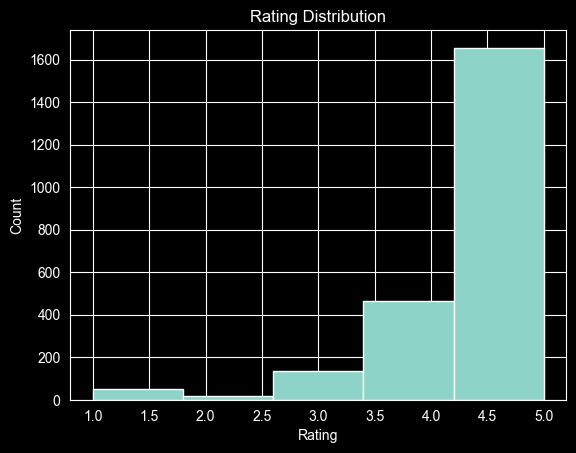

In [3]:
import matplotlib.pyplot as plt

df["rating"].hist(bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.show()

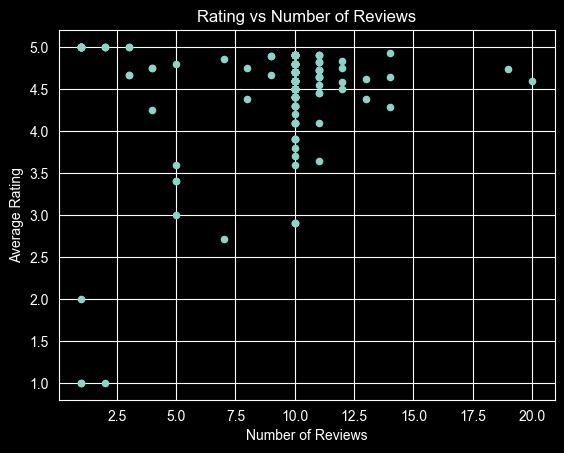

In [11]:
product_stats = df.groupby("product_name").agg(
    avg_rating=("rating", "mean"),
    review_count=("rating", "count")
)

product_stats.plot.scatter(x="review_count", y="avg_rating")

plt.title("Rating vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Average Rating")

plt.show()

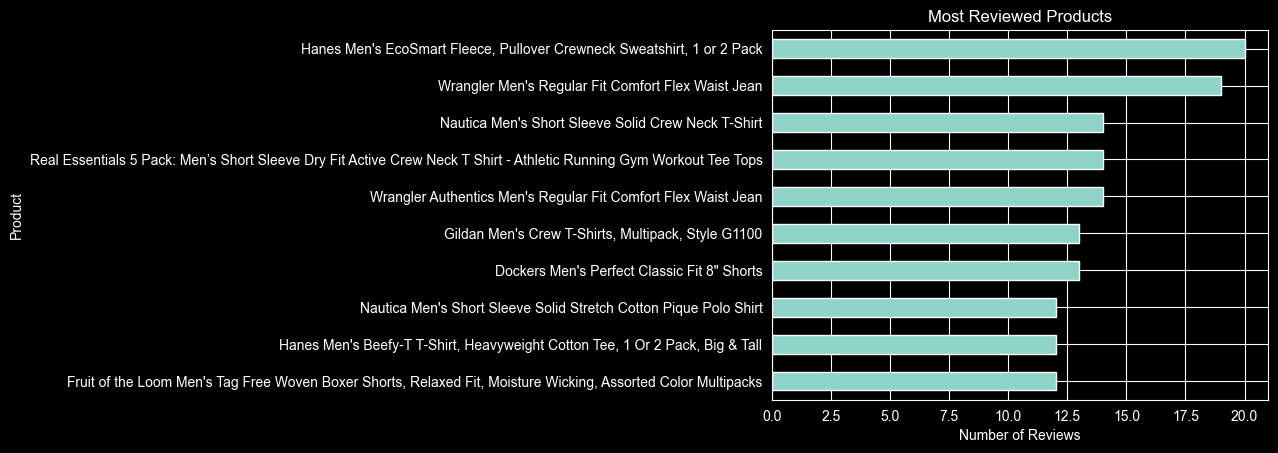

In [8]:
top_reviewed = df["product_name"].value_counts().head(10)

top_reviewed.plot(kind="barh")

plt.title("Most Reviewed Products")
plt.xlabel("Number of Reviews")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.show()

In [9]:
comparison = pd.DataFrame({
    "Model": ["Content-Based", "KNN", "Hybrid"],
    "Accuracy": [0.91, 0.84, 0.97]
})

comparison

,Model,Accuracy
0,Content-Based,0.91
1,KNN,0.84
2,Hybrid,0.97


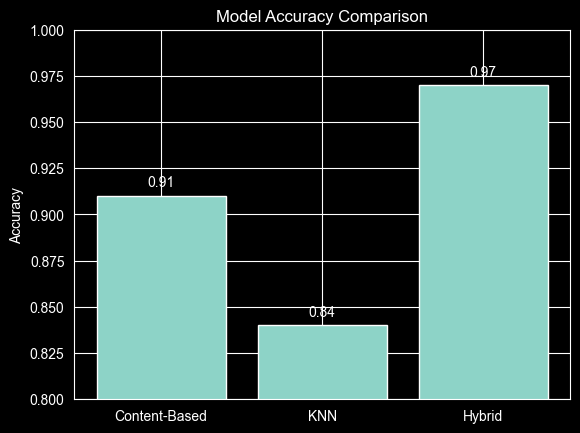

In [7]:
models = ["Content-Based", "KNN", "Hybrid"]
accuracy = [0.91, 0.84, 0.97]

plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)

for i, v in enumerate(accuracy):
    plt.text(i, v + 0.005, str(v), ha='center')

plt.show()

In [18]:
import pandas as pd

DATA_PATH = "C:\\Users\\amitb\\PycharmProjects\\ML _Project\\data\\processed\\cleaned_products.csv"

df = pd.read_csv(DATA_PATH)

# Example: take top 5 products as recommendations
results = df.sort_values("weighted_rating", ascending=False).head(5)

rec_df = results[["product_name"]]

merged = rec_df.merge(
    df[["product_name", "rating"]],
    on="product_name",
    how="left"
)

merged["rating"] = merged["rating"].fillna(0)

# Define relevance
merged["actual"] = merged["rating"].apply(lambda x: 1 if x >= 4 else 0)

# Recommended items are predicted relevant
merged["predicted"] = 1

y_true = merged["actual"]
y_pred = merged["predicted"]

merged

,product_name,rating,actual,predicted
0,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
1,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
2,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
3,Nautica Men's Short Sleeve Solid Stretch Cotto...,4.0,1,1
4,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
5,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
6,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
7,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
8,Nautica Men's Short Sleeve Solid Stretch Cotto...,5.0,1,1
9,Nautica Men's Short Sleeve Solid Stretch Cotto...,4.0,1,1


**ROC Curve**

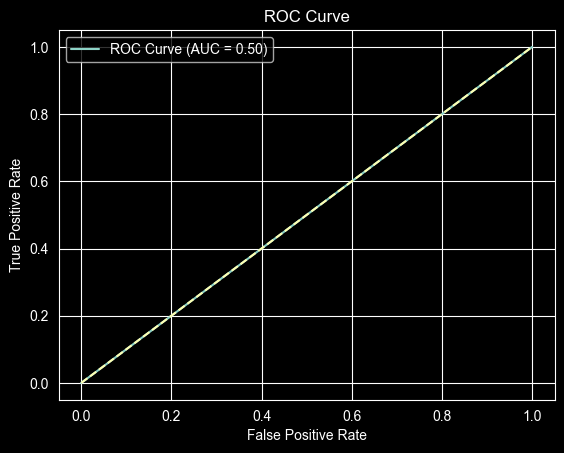

In [19]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()

plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % roc_auc)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()

**Confusion Matrix**

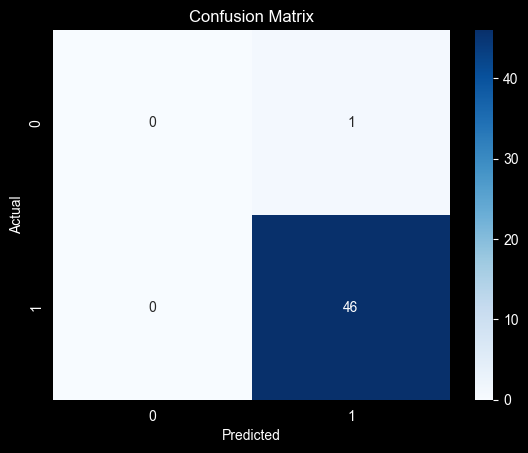

In [20]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()